In [54]:
# Standard libraries
import sys

#Interactive library

import plotly.express as px

# Data handling
import numpy as np
import pandas as pd

# Machine learning
import sklearn

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

##Load and adjust the data:##

In [55]:
directory_data = "../data" # Adjust the path to your data directory if necessary
movies = pd.read_csv(f"{directory_data}/raw/movies.csv")  # Adjust the path to your data directory if necessary
ratings = pd.read_csv(f"{directory_data}/raw/ratings.csv")
tags = pd.read_csv(f"{directory_data}/raw/tags.csv")

In [56]:
print(movies.head())
print(ratings.head())
print(tags.head())


   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating   timestamp
0       1        1     4.0  1225734739
1       1      110     4.0  1225865086
2       1      158     4.0  1225733503
3       1      260     4.5  1225735204
4       1      356     5.0  1225735119
   userId  movieId            tag   timestamp
0      10      260   good vs evil  1430666558
1      10      260  Harrison Ford  1430666505
2      10      260         sci-fi

**Check if missing data:**

In [57]:
movies.isna().sum()
ratings.isna().sum()
tags.isna().sum()

userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

In [58]:
tags[tags.isna().any(axis=1)]

,userId,movieId,tag,timestamp
530012,104413,123,NaN,1199450867
530013,104413,346,NaN,1199451946
530017,104413,1184,NaN,1199452261
530024,104413,1785,NaN,1199452006
530025,104413,2194,NaN,1199450677
530027,104413,2691,NaN,1199451002
530035,104413,4103,NaN,1199451920
530037,104413,4473,NaN,1199451040
530039,104413,4616,NaN,1199452441
530055,104413,7624,NaN,1199452266


**check if duplicates**

In [59]:
movies.duplicated().sum()
ratings.duplicated().sum()
tags.duplicated().sum()

np.int64(0)

##structure it:##

In [60]:
print("MOVIES DATASET: ")
print(f"Shape: {movies.shape}")
print (f"Columns: {movies.columns.tolist()}")

print("\nRATINGS DATASET: ")
print(f"Shape: {ratings.shape}")
print(f"Columns: {ratings.columns.tolist()}")

print("\nTAGS DATASET: ")
print(f"Shape: {tags.shape}")
print(f"Columns: {tags.columns.tolist()}")


MOVIES DATASET: 
Shape: (86537, 3)
Columns: ['movieId', 'title', 'genres']

RATINGS DATASET: 
Shape: (33832162, 4)
Columns: ['userId', 'movieId', 'rating', 'timestamp']

TAGS DATASET: 
Shape: (2328315, 4)
Columns: ['userId', 'movieId', 'tag', 'timestamp']


userID = anonymized user
movieID = movie beeing rated
rating = rating given by user
timestamp = time when the rating was submitted

What is the interval for the scores?

In [61]:
ratings["rating"].min(), ratings["rating"].max()



(np.float64(0.5), np.float64(5.0))

##Display the data:##

In [62]:
display(movies.head())
display(ratings.head())
display(tags.head())

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


multiple genres for one movie. Might be a way to sort how alike two mives are.

##genres: 
how do they look?

In [63]:
movies["genres"].head()


0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
Name: genres, dtype: str

they are spearated by|| and includes several per movie. 
Split them. how many categories? which are the most used? anomalies?

In [64]:
movies["genres"].str.split("|").explode().nunique()

20

In [65]:
movies["genres"].str.split("|").explode().value_counts()


genres
Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301
Western                1690
Musical                1059
Film-Noir               354
IMAX                    195
Name: count, dtype: int64

In [66]:
genre = movies["genres"].str.split("|").explode()
genre_counts = genre.value_counts()


figure = px.bar(
    x=genre_counts.index,
    y=genre_counts.values,
    labels={"x": "Genre", "y": "number of movies"},
    title="Number of movies by genre"
)

figure = px.bar(
    genre_counts.sort_values(ascending=False),
    labels={"value": "Number of movies", "index": "Genre"},
    title="Number of movies by genre"

)

figure.show()

##What is included in "no genre listed"?
explore:  
Is tehre ratings to these movies?  
what kind of movies are they?  
From which year is the movie?

**Are there any ratings?**  

In [67]:
no_genre_movies = movies[movies["genres"] == "(no genres listed)"]

ratings[ratings["movieId"].isin(no_genre_movies["movieId"])].shape

(56059, 4)

This shows 56059 ratings in the category "no genre" but not how many movies that has ratings.

In [68]:
ratings[ratings["movieId"].isin(no_genre_movies["movieId"])]["movieId"].nunique()

6521

It does not look like the category "no genre" is affected by not beeing rated.

##From which year is these movies?  
I need to split the name category to show year separately from moviename.  
I will try regex to extract the year:

In [69]:
movies["year"] = movies["title"].str.extract(r"\((\d{4})\)").astype(float)
movies["year"] = pd.to_numeric(movies["year"], errors="coerce")

**regex vocabulary:**
\( = left parenthesis
\d/{4} = four numbers
\) = right parenthesis

In [70]:
no_genre_movies = movies[movies["genres"] == "(no genres listed)"]
no_genre_movies["decade"] = (no_genre_movies["year"] // 10) * 10

figure = px.bar(
    x=no_genre_movies["decade"].value_counts().index,
    y=no_genre_movies["decade"].value_counts().values,
    labels={"x": "decade", "y": "number of movies"},
    title="Number of movies without genres by decade"
)

figure = px.bar(
    no_genre_movies["decade"].value_counts().sort_index(),
    labels={"value": "Number of movies", "index": "Decade"},
    title="Number of movies without genres by decade"
)


figure.show()


Why the drop in unrated movies in the 2020's?

In [71]:
movies["decade"] = movies["year"] // 10 * 10
movies_per_decade = movies["decade"].value_counts().sort_index()

The raw counts of movies without genre decrease in the 2020s, but this may be due to fewer movies being present in the dataset for that decade. To account for this, the proportion of movies without genre was calculated.
occording to movielens the dataset has been latest update in 2018.

In [72]:
no_genre_per_decade = no_genre_movies["decade"].value_counts() 
movies_per_decade = movies["decade"].value_counts().sort_index()

combined = pd.concat([movies_per_decade, no_genre_per_decade], axis=1)
combined.columns = ["total_movies", "no_genre_movies"]

combined = combined.fillna(0)
combined["percentage_no_genre"] = (
    combined["no_genre_movies"] / combined["total_movies"]
) * 100
combined

,total_movies,no_genre_movies,percentage_no_genre
decade,,,
1870.0,3,1,33.333333
1880.0,12,2,16.666667
1890.0,201,64,31.840796
1900.0,298,80,26.845638
1910.0,382,58,15.183246
1920.0,733,83,11.323329
1930.0,2589,255,9.849363
1940.0,2759,197,7.140268
1950.0,3601,297,8.247709


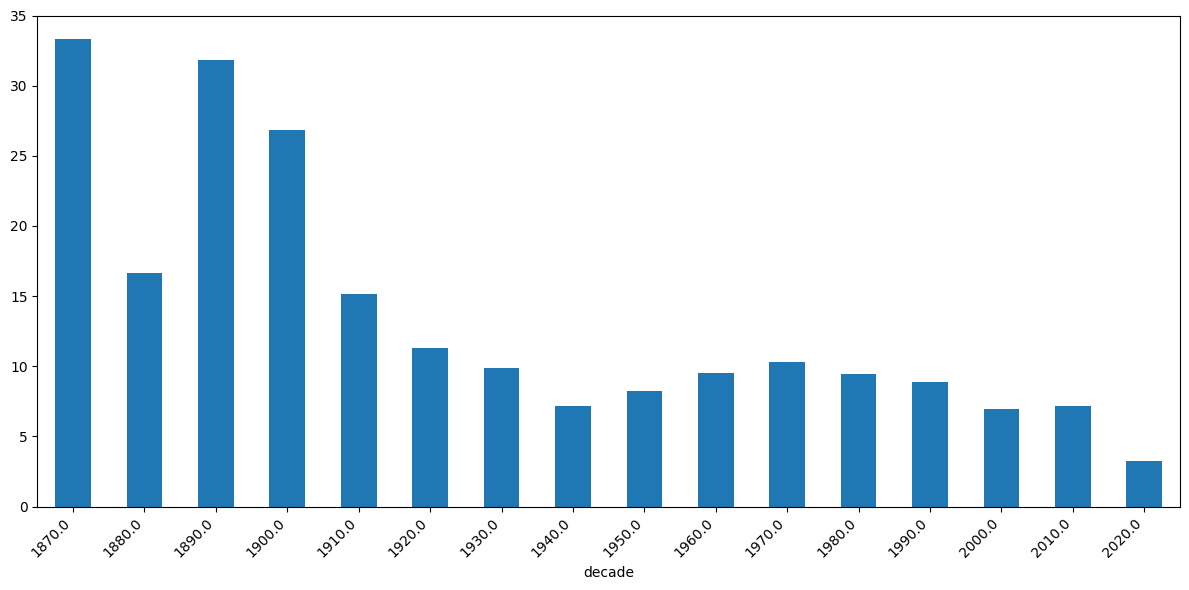

In [73]:
combined["percentage_no_genre"].plot(kind="bar", figsize=(12, 6))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Make a visual comparison over time:  
I reuse the log-scale function from the cours "databehandling" that I used to compare Autralias participation i summer vs. Winter olympics. It gives a better comparison for the genreless movies to all movies in the set.

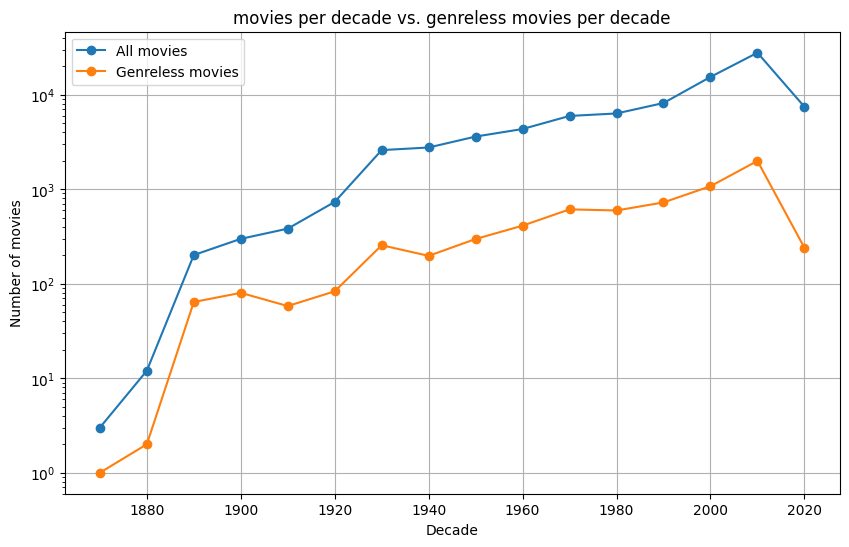

In [74]:
combined[["total_movies", "no_genre_movies"]].plot(
    kind="line",  
    figsize=(10, 6),
    marker='o'
)

plt.yscale("log")  # Use logarithmic scale for better visibility

plt.title("movies per decade vs. genreless movies per decade")
plt.xlabel("Decade")
plt.ylabel("Number of movies")
plt.legend(["All movies", "Genreless movies"])
plt.grid(True)
plt.show()

copilot input:
Key insight for your recommendation system: Most of your training data comes from 1990-2015 movies. If you're building recommendations, be aware that:

Very old movies (pre-1980) are underrepresented
Recent movies (post-2018) are missing
Your genreless movies might need special handling since they lack genre information for clustering/similarity calculations

The dataset grows strongly from the 1980s onwards. Movies without genre information follow a similar growth pattern. This suggests that missing genre information is largely related to the increasing size of the dataset rather than being concentrated in specific historical periods.

##What am I missing?  


In [75]:
no_genre_movies.title.sample(20)



28601                          Senior Week (1988)
38310                                   Vogelfrei
45144                               Poveda (2016)
29816              È arrivato mio fratello (1985)
35672               Hollywood My Home Town (1965)
72518               Young Love, First Love (1979)
58080                                Via Carpatia
38824                            Winepress (1974)
36176                    Le bonheur d'Elza (2011)
60177             I'm Looking at You, Mary (2000)
28418          Somebody Killed Her Husband (1978)
50175       I Know My First Name Is Steven (1989)
47642                             Marriage (1978)
50340                 The Thought Exchange (2012)
41870                       In Celebration (1975)
30111                        Anni ruggenti (1962)
36471         Marco Polo: One Hundred Eyes (2015)
37181    Le Mans scorciatoia per l'inferno (1970)
42365                    Death of a Shadow (2012)
33843              I Just Want to Kiss You (1998)


Irealized that I might want to save this sample a little too late. But i could use the index to save them:

In [76]:
sample_20_movie_ids = [
    40227,64466, 33705, 75465, 51926, 
    72508, 30072, 46811, 80797, 47885, 
    69886, 58849, 47176, 25350, 57030, 
    76271, 36054, 36305, 70646, 54737  
]

sample_movies = no_genre_movies.loc[sample_20_movie_ids]

sample_movies[["movieId", "title", "genres"]]

,movieId,title,genres
40227,158062,Daughter... Father... Daughter (2011),(no genres listed)
64466,210147,Kairos (2019),(no genres listed)
33705,143147,Sandcastles (1972),(no genres listed)
75465,248212,Box Office Smash (2018),(no genres listed)
51926,182765,Rooster: Spurs of Death!,(no genres listed)
72508,234496,Bad Ben 7: The Haunted Highway (2019),(no genres listed)
30072,134973,Quelle strane occasioni (1976),(no genres listed)
46811,172047,The Harvest of Sorrow (1998),(no genres listed)
80797,270814,Black Ice (2020),(no genres listed)
47885,174247,The Seven Ages (1905),(no genres listed)


 ##IMDB-serch for information/genre:
 
 - Daughter... Father... Daughter (2011): Drama  
 Dokhtar... pedar... dokhtar 
 - Kairos (2019):  drama  
 - Sandcastles (1972): drama|romance  
 - Box Office Smash (2018): short|drama  
 -  Rooster: Spurs of Death!: drama  
 -  Rooster: Spurs of Death!: drama  
 - Quelle strane occasioni (1976): comedy  
 - The Harvest of Sorrow (1998): documentary|biography  
 - The Seven Ages (1905): short|comedy|drama|romance  
 -   Free Man (2010): short|drama|fantasy|romance  
 - Shiro and Marilyn (1988): drama|family  
 Marilyn ni aitai  
 - Львиная доля (2001): action|crime  
 -  Poster Girl (2010): documentary|short|biography|war  
 - What You Gonna Do When the World's on Fire? (2...: documentary
 - Death of an Angel (1952): crime|drama|mystery  
 - Nude Odeon (1978): documentary  
 -  Il Bi e il Ba (1986): comedy  
 - Chronicle of the End of the World (2012):adventure|drama|comedy|sci-fi  
 -  Bubblegum: drama|romance




##What about the tags?
I serached the sample manually through imdb.com. that shows that there should be genres. These are not so obscure that they are without. 
Maybe tags can give me more information? tags are made by users and can maybe give additonal information.

In [77]:
tags_no_genre = tags[tags["movieId"].isin(no_genre_movies["movieId"])]
tags_no_genre["tag"].value_counts().head(20)

tag
woman director      282
cinematography      116
short               106
horror               99
musical              94
documentary          92
murder               87
original horror      79
supernatural         77
great acting         76
mental illness       76
short film           75
coming of age        72
cults                68
independent film     68
music                67
BD-R                 66
demonology           62
thriller             59
Criterion            56
Name: count, dtype: int64

There are many tags that could be called genres. But I want to crosscheck tags to the 20 to which I found genre on IMDB to see similartities och anomalies.

In [78]:
tags_sample = tags[tags["movieId"].isin(sample_movies["movieId"])]

tags_sample = tags_sample.merge(
    sample_movies[["movieId", "title"]],
    on="movieId"
)

tags_sample[["title", "tag"]]



,title,tag
0,The Harvest of Sorrow (1998),documentary
1,The Harvest of Sorrow (1998),music
2,Poster Girl (2010),disability
3,Poster Girl (2010),iraq war veteran
4,Poster Girl (2010),woman director
5,Nude Odeon (1978),fake documentary
6,Nude Odeon (1978),nudism
7,Nude Odeon (1978),orgy
8,Nude Odeon (1978),sex
9,Rooster: Spurs of Death!,exploitation


In [79]:
tags_per_movie = tags_sample.groupby("title")["tag"].apply(list)

tags_per_movie

title
Bad Ben 7: The Haunted Highway (2019)                                      [found footage]
Daughter... Father... Daughter (2011)                                  [Iran, Middle East]
Death of an Angel (1952)                 [based on play, Hammer Film Productions, physi...
Nude Odeon (1978)                                    [fake documentary, nudism, orgy, sex]
Poster Girl (2010)                          [disability, iraq war veteran, woman director]
Rooster: Spurs of Death!                                                    [exploitation]
Shiro and Marilyn (1988)                             [Courage, Dogs, Japan, Love, Okinawa]
The Harvest of Sorrow (1998)                                          [documentary, music]
Name: tag, dtype: object

Manual inspection shows that al movies in the sample labeled "(no genres listed)" actually have genre information on external sources such as IMDb. In the MovieLens dataset, user tags sometimes provide descriptive information about the movie, but in this sample, they rarely correspond directly to genre categories.

Claude suggests (keeping it here for later reference):  
 1. Extract pseudo-genres from tags (Recommended for your system)
Many tags ARE genre descriptors:

"documentary", "exploitation", "found footage" → actual genre info
"Iran, Middle East", "based on play" → contextual info
You could extract tags that look like genres and use them as the missing genre information.

2. Use tags as similarity features directly
Instead of forcing genres, use the tags themselves for recommendations:

Two movies with similar tags → similar content
This works for both genreless and regular movies
3. Handle them separately in your algorithm
Genreless movies → recommend based on user ratings only (collaborative filtering)
Movies with genres → use content-based + ratings (hybrid)
4. Manual assignment
Based on your IMDB research + tags, manually assign genres for these critical movies.

For your recommendation system, I'd suggest:

Extract genre-like tags and create a "reconstructed_genres" column for the genreless movies:

Then you have two paths:

Path A: Fill missing genres with these inferred genres
Path B: Use both official genres + tags as separate features for similarity
Which approach fits better with your recommendation algorithm — content-based (genre similarity) or collaborative (rating similarity)?

Claude Haiku 4.5 • 0.33x

*For movies where genre information is missing*, user-generated tags can provide alternative descriptive features. Therefore, tags can be used as an additional source of content information when genre metadata is unavailable.

# plan for no genre -  content based system:
- 1) genres  
- 2) tags  
- 3) neither - erase


**Ratings**  
How are they distributed?  


In [80]:
sorted(ratings["rating"].unique())

[np.float64(0.5),
 np.float64(1.0),
 np.float64(1.5),
 np.float64(2.0),
 np.float64(2.5),
 np.float64(3.0),
 np.float64(3.5),
 np.float64(4.0),
 np.float64(4.5),
 np.float64(5.0)]

sorted by intervals of 0.5

**How many ratings per movie?

In [81]:
ratings.groupby("movieId").size().describe()

count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
dtype: float64

**very skewed ratings.**  
The dataset shows a very skewed distribution of ratings per movie. While the mean number of ratings is 406, the median is only 5. This indicates that a small number of very popular movies dominate the dataset. 
std is extremely large. That indicate extrem outliers.
This imbalance can affect recommendation systems since movies with few ratings are statistically unreliable.

**How can I solve this?** 
- minimum number of ratings: min_ratings = 20  
- weighted ratings: 
weighted_rating (IMDB-solution) =
(v/(v+m)) * R + (m/(v+m)) * C
where:  
R = movie rating
v = number of ratings
C = global mean
m = minimum ratings  
- Bayesian average:  


<Axes: >

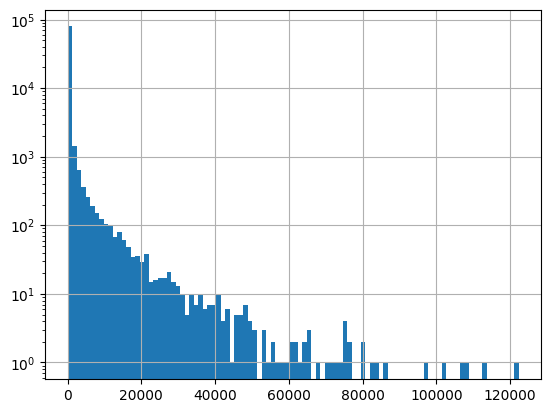

In [82]:
ratings_per_movie = ratings.groupby("movieId").size()

ratings_per_movie.hist(bins=100, log=True)


long-tail distribution.

**ratings per user:**  
I hav a nagging feeling that tere might be some inconsistencies in the reviewer part also. In the beginning it seemed like there already where many movies reviewed by a few userIds


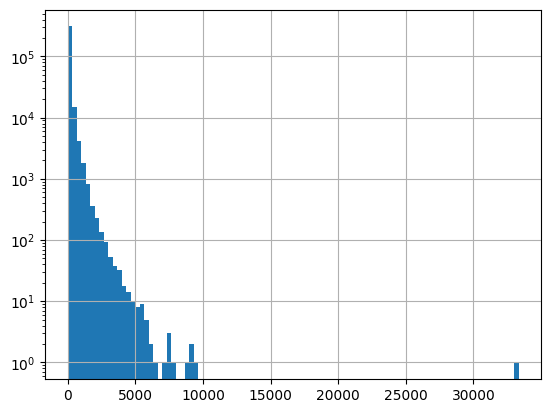

In [83]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.name = "ratings_per_user"

ratings_per_user.describe()
ratings_per_user.hist(bins=100, log=True)
fig = px.histogram(
    ratings_per_user, 
    nbins=100, 
    log_y=True, 
    labels={"value": "Ratings per user"},
    title="Distribution of number of ratings per user (log-scale)"
)
fig.update_layout(
    xaxis_title="Number of ratings per user", 
    yaxis_title="Number of users"
)
fig.show()

The number of ratings per user also gives scewed results. One user has given more than 30 000 ratings. The logscale shows it viusally.

In [84]:

fig = px.histogram(
    ratings_per_user, 
    nbins=100, 
    labels={"value": "Ratings per user"},
    title="Distribution of number of ratings per user"
)
fig.update_layout(
    xaxis_title="Number of ratings per user", 
    yaxis_title="Number of users"
)
fig.show()

**critical bias**
The distribution of ratings per user is highly skewed.  
One user rates more than 30 000 movies while most users rate very few movies. 
Without a logarithmic scale the extreme outliers are difficult to see because most users have very few ratings.
Using a log scale on the y-axis makes the long-tail distribution visible.

**Because I am curious**
The one power-rater. Has he seen all the movies?  
I am wondering if the data could give me some insight in age, period of time rating.



In [85]:
ratings_per_user = ratings.groupby("userId").size()
ratings_per_user.sort_values(ascending=False).head(1)


userId
189614    33332
dtype: int64

I got the userId. Now I want o know timestamps for the earliest and latest dates.

In [86]:
user_ratings = ratings[ratings["userId"] == 189614 ]
user_ratings_sorted = user_ratings.sort_values("timestamp")


user_ratings_sorted["datetime"] = pd.to_datetime(
    user_ratings_sorted["timestamp"], 
    unit="s"
)
user_ratings_sorted[["movieId", "rating", "datetime"]]

,movieId,rating,datetime
19358688,116897,4.0,2015-12-15 06:59:27
19357387,106782,4.0,2015-12-15 06:59:27
19354567,86057,4.5,2015-12-15 06:59:27
19353160,74014,4.0,2015-12-15 06:59:28
19360930,132456,4.0,2015-12-15 06:59:28
...,...,...,...
19375169,210129,4.0,2020-06-12 15:34:59
19373695,198875,3.0,2020-06-12 15:34:59
19375559,214838,3.5,2020-06-12 15:35:00
19373991,200744,3.0,2020-06-12 15:35:00


Inspection of timestamps shows that many ratings are submitted within the same second, suggesting that users often rate movies in batches rather than immediately after watching them. with some math the average rating per day during the timeinterval is 20 movieratings per day. It is possible to do arating, bit is it possible to have watched that many movies. Iam considering if I can get som kind of feeling for age through moviechoices?


In [87]:
user_movies = user_ratings.merge(movies, on="movieId", how="inner")
user_movies["title"].head()

user_movies["year"] = user_movies["title"].str.extract(r"\((\d{4})\)").astype(float)

user_movies["year"].value_counts().sort_index()

year
1878.0       1
1888.0       3
1890.0       2
1891.0       2
1892.0       1
          ... 
2015.0    1343
2016.0    1368
2017.0    1280
2018.0    1022
2019.0     253
Name: count, Length: 131, dtype: int64

The person has watched 3.6 movies per day during 2015-2020 to be able to rate nly the movies produced during the same period (5266 movies). It doe ssound like a lot but not impossible. 
I want to compare how many movie swas registered during the same period to how many the person rated.

In [88]:
movies["year"].value_counts().sort_index()

movies[(movies["year"] >= 2015) & (movies["year"] <=2020)]["year"].value_counts().sort_index()

year
2015.0    3045
2016.0    3144
2017.0    3232
2018.0    3172
2019.0    3058
2020.0    2628
Name: count, dtype: int64

looking at the results the person has been rating over 40% of all movies in the system from 2015-2017.  
Reading about movielens they encouraged users to rate movies by first letting them rate categories like genres, and thereafter movies to be able to faster get the users better recommendations. I want to viualize how the user ratings compares to the movies made year to year.

In [89]:
total_movies_year = movies.groupby("year").size()
user_movie_year = user_movies.groupby("year").size()
comparison = pd.concat([total_movies_year, user_movie_year], axis=1)
comparison.columns = ["total_movies", "user_rated"]
comparison = comparison.fillna(0)
comparison["not_rated"] = comparison["total_movies"] - comparison["user_rated"]

plot_data = comparison.reset_index().melt(
    id_vars="year",
    value_vars=["user_rated", "not_rated"],
    var_name="category",
    value_name="movies"
)

plot_data["total_movies"] = plot_data["year"].map(comparison["total_movies"])

fig = px.bar(
    comparison.reset_index(),
    x="year",
    y=["user_rated", "not_rated"],
    title= "Movies rated vs not rated by user per year",
    labels={
        "value": "Number of movies", 
        "year": "Year", 
        "variable": "category"
    }
)
fig.show()

somethings wrong in the 1920-20*s the user has rated more movies than what was produced

In [90]:
plot_compare = comparison.reset_index()

fig = px.bar(
    plot_compare,
    x="year",
    y=["total_movies", "user_rated"],
    barmode="group",
    labels={
        "value": "Number of movies",
        "year": "Year",
        "variable": "Category"
    },
    title="All movies vs movies rated by superuser per year"
)

fig.show()

There is something wring with the hoover function but it is not relevant for the assignment, so I leave i be.

In [ ]:
comparison.loc[1915]

total_movies    41.0
user_rated      21.0
not_rated       20.0
Name: 1915.0, dtype: float64

Top 10 most active users:
userId
189614    33332
48766      9554
207216     9178
175998     9016
76618      8919
230765     7719
184775     7535
236260     7488
233891     7372
214831     7266
dtype: int64

Total number of ratings in the dataset: 33832162
The top 1% most active users account for 16.35% of all ratings.


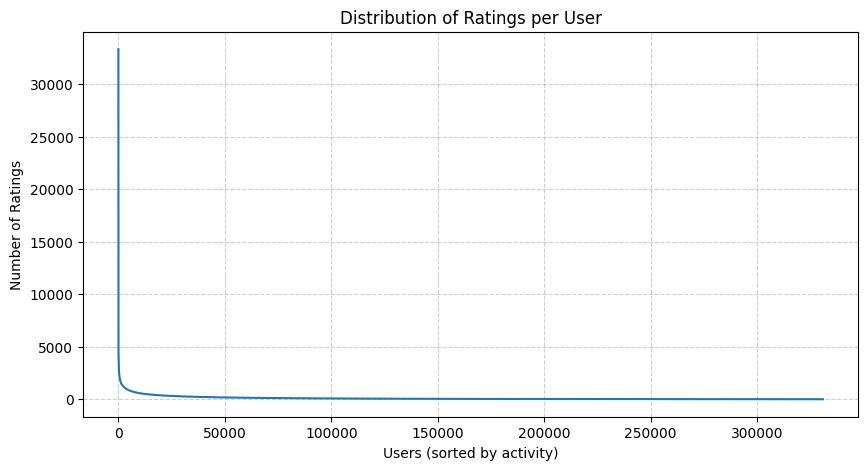

In [97]:

df = ratings 

# 2.count number of ratings per user
user_counts = df.groupby('userId').size().sort_values(ascending=False)

# 3. identify Superusers (e.g. user 189614)
print("Top 10 most active users:")
print(user_counts.head(10))

# 4. check what percentage of ALL ratings the top 1% of users account for
top_1_percent_count = int(len(user_counts) * 0.01)
top_users_sum = user_counts.head(top_1_percent_count).sum()
total_ratings = len(df)
percentage = (top_users_sum / total_ratings) * 100

print(f"\nTotal number of ratings in the dataset: {total_ratings}")
print(f"The top 1% most active users account for {percentage:.2f}% of all ratings.")

# 5. visualize distribution (Long Tail)
plt.figure(figsize=(10, 5))
plt.plot(user_counts.values)
plt.title('Distribution of Ratings per User')
plt.xlabel('Users (sorted by activity)')
plt.ylabel('Number of Ratings')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()










**note to me**
transformera data (log)

filtrera extremvärden

normalisera features

**code to CLEAN (if I decide to remove them)**
# put a reasonable threshold for max ratings per user (e.g. 2000)
limit = 2000
clean_df = df[df.groupby('userId')['userId'].transform('size') <= limit]

print(f"Efter rensning (max {limit} betyg):")
print(f"Antal rader kvar: {len(clean_df)} (Tidigare: {len(df)})")

decitions to make:  
- keep superusers  
 + good to find beter recommendations  
 - risk for bias
 - not representatuve for average user
 

The ratings distribution is highly skewed. The top 1% most active users account for 16.35% of all ratings. This indicates a long-tail distribution where a small number of users contribute a disproportionate amount of data. While these users provide strong signals that help identify similarities between movies, the dataset may also be biased towards the preferences of highly active users rather than representing the typical user.